# Scheduler V4 (Backup)


In [38]:
import pandas as pd
import numpy as np

from datetime import datetime, timedelta, time

# ===============================
# Load datasets
# ===============================

employees = pd.read_csv("employees.csv")

employee_score = pd.read_csv("employee_score.csv")

projects = pd.read_csv("projects.csv")

project_tasks = pd.read_csv("project_tasks.csv")

# ===============================
# Initial Scheduler State
# ===============================

employee_score["available_at"] = datetime(
    2026,
    7,
    6,
    8,
    30
)

employee_score["worked_hours_week"] = 0.0

project_tasks["status"] = "Pending"


In [39]:
employee_leaves = pd.read_csv("employee_leaves.csv")

employee_leaves["start_date"] = pd.to_datetime(
    employee_leaves["start_date"]
)

employee_leaves["end_date"] = pd.to_datetime(
    employee_leaves["end_date"]
)

In [40]:
def is_on_leave(employee_id, date):

    leave = employee_leaves[

        (employee_leaves["employee_id"] == employee_id)

        &

        (employee_leaves["start_date"] <= date)

        &

        (employee_leaves["end_date"] >= date)

    ]

    return len(leave) > 0

In [41]:
# ======================================
# Working calendar
# ======================================

WORK_START_MORNING = time(8,30)
WORK_END_MORNING = time(12,0)

WORK_START_AFTERNOON = time(13,0)
WORK_END_AFTERNOON = time(17,0)

MAX_WEEK_HOURS = 38

BREAK_DURATION = 0.5      # 30 minutes


# ======================================
# Go to next working period
# ======================================

def next_working_time(dt):

    while dt.weekday() >= 5:

        dt = datetime.combine(
            dt.date() + timedelta(days=1),
            WORK_START_MORNING
        )

    if dt.time() < WORK_START_MORNING:

        return datetime.combine(
            dt.date(),
            WORK_START_MORNING
        )

    if WORK_END_MORNING <= dt.time() < WORK_START_AFTERNOON:

        return datetime.combine(
            dt.date(),
            WORK_START_AFTERNOON
        )

    if dt.time() >= WORK_END_AFTERNOON:

        dt = datetime.combine(
            dt.date() + timedelta(days=1),
            WORK_START_MORNING
        )

        while dt.weekday() >= 5:

            dt = datetime.combine(
                dt.date() + timedelta(days=1),
                WORK_START_MORNING
            )

        return dt

    return dt


# ======================================
# Add working hours
# ======================================

def add_working_hours(start, hours):

    current = next_working_time(start)

    remaining = hours

    while remaining > 0:

        current = next_working_time(current)

        if current.time() < WORK_END_MORNING:

            period_end = datetime.combine(
                current.date(),
                WORK_END_MORNING
            )

        else:

            period_end = datetime.combine(
                current.date(),
                WORK_END_AFTERNOON
            )

        available = (
            period_end - current
        ).total_seconds() / 3600

        if remaining <= available:

            current += timedelta(hours=remaining)

            remaining = 0

        else:

            current = period_end

            remaining -= available

    return current

In [42]:
# ======================================
# Working Calendar
# ======================================

WORK_START_MORNING = time(8,30)
WORK_END_MORNING = time(12,0)

WORK_START_AFTERNOON = time(13,0)
WORK_END_AFTERNOON = time(17,0)

MAX_WEEK_HOURS = 38
BREAK_DURATION = 0.5


# ======================================
# Go to next working period
# ======================================

def next_working_time(dt):

    while dt.weekday() >= 5:
        dt = datetime.combine(
            dt.date() + timedelta(days=1),
            WORK_START_MORNING
        )

    if dt.time() < WORK_START_MORNING:
        return datetime.combine(
            dt.date(),
            WORK_START_MORNING
        )

    if WORK_END_MORNING <= dt.time() < WORK_START_AFTERNOON:
        return datetime.combine(
            dt.date(),
            WORK_START_AFTERNOON
        )

    if dt.time() >= WORK_END_AFTERNOON:

        dt = datetime.combine(
            dt.date() + timedelta(days=1),
            WORK_START_MORNING
        )

        while dt.weekday() >= 5:
            dt = datetime.combine(
                dt.date() + timedelta(days=1),
                WORK_START_MORNING
            )

    return dt


# ======================================
# Add working hours
# ======================================

def add_working_hours(start, hours):

    current = next_working_time(start)

    remaining = hours

    while remaining > 0:

        current = next_working_time(current)

        if current.time() < WORK_END_MORNING:
            period_end = datetime.combine(
                current.date(),
                WORK_END_MORNING
            )
        else:
            period_end = datetime.combine(
                current.date(),
                WORK_END_AFTERNOON
            )

        available = (
            period_end-current
        ).total_seconds()/3600

        if remaining <= available:

            current += timedelta(hours=remaining)
            remaining = 0

        else:

            current = period_end
            remaining -= available

    return current


# ======================================
# PRIMARY EMPLOYEE
# ======================================

def get_best_employee(employee_score,
                      department,
                      duration):

    dept = employee_score[
        employee_score["department"] == department
    ].copy()

    dept = dept[
        dept["worked_hours_week"] + duration <= MAX_WEEK_HOURS
    ]

    if dept.empty:

        employee_score.loc[
            employee_score["department"] == department,
            "worked_hours_week"
        ] = 0

        dept = employee_score[
            employee_score["department"] == department
        ].copy()

    dept = dept.sort_values(

        by=[
            "available_at",
            "performance_score"
        ],

        ascending=[
            True,
            False
        ]

    )

    for _, emp in dept.iterrows():

        if not is_on_leave(

            emp["employee_id"],
            emp["available_at"]

        ):

            return emp

    return None


# ======================================
# BACKUP EMPLOYEE
# ======================================

def get_backup_employee(
    employee_score,
    department,
    duration,
    primary_employee_id,
    task_start
):

    dept = employee_score[
        employee_score["department"] == department
    ].copy()

    dept = dept[
        dept["employee_id"] != primary_employee_id
    ]

    dept = dept[
        dept["worked_hours_week"] + duration <= MAX_WEEK_HOURS
    ]

    # must already be available
    dept = dept[
        dept["available_at"] <= task_start
    ]

    dept = dept[
        ~dept.apply(

            lambda row:

            is_on_leave(
                row["employee_id"],
                task_start
            ),

            axis=1

        )
    ]

    if dept.empty:
        return None

    dept = dept.sort_values(

        by=[
            "performance_score",
            "available_at"
        ],

        ascending=[
            False,
            True
        ]

    )

    return dept.iloc[0]

In [44]:
planning = []

projects = projects.sort_values("project_id")

for _, project in projects.iterrows():

    project_id = project["project_id"]

    project_features = project_tasks[
        project_tasks["project_id"] == project_id
    ]

    for feature in project_features["feature"].unique():

        project_start = pd.to_datetime(
            project["start_date"]
        )

        previous_end = datetime.combine(
            project_start.date(),
            WORK_START_MORNING
        )

        for stage in [1,2,3]:

            task = project_features[

                (project_features["feature"]==feature)

                &

                (project_features["workflow_order"]==stage)

            ]

            if task.empty:
                continue

            task = task.iloc[0]

            employee = get_best_employee(

                employee_score,

                task["department"],

                task["estimated_hours"]

            )

            if employee is None:

                mask = employee_score["department"] == task["department"]

                employee_score.loc[
                    mask,
                    "worked_hours_week"
                ] = 0

                employee_score.loc[
                    mask,
                    "available_at"
                ] = employee_score.loc[
                    mask,
                    "available_at"
                ] + timedelta(days=7)

                employee = get_best_employee(

                    employee_score,

                    task["department"],

                    task["estimated_hours"]

                )

            # Still nobody
            if employee is None:

                planning.append({

                    "project_id":project_id,

                    "task_id":task["task_id"],

                    "feature":task["feature"],

                    "workflow_order":task["workflow_order"],

                    "department":task["department"],

                    "employee_id":"No Employee",

                    "team":"-",

                    "backup_employee":"No Backup",

                    "backup_team":"-",

                    "start":None,

                    "end":None,

                    "worked_hours":task["estimated_hours"],

                    "break_minutes":0,

                    "leave":True

                })

                continue


            start = max(

                employee["available_at"],

                previous_end

            )

            start = next_working_time(start)

            backup = get_backup_employee(

                employee_score,

                task["department"],

                task["estimated_hours"],

                employee["employee_id"],

                start

            )

            end = add_working_hours(

                start,

                task["estimated_hours"]

            )

            next_available = add_working_hours(

                end,

                BREAK_DURATION

            )

            planning.append({

                "project_id":project_id,

                "task_id":task["task_id"],

                "feature":task["feature"],

                "workflow_order":task["workflow_order"],

                "department":task["department"],

                "employee_id":employee["employee_id"],

                "team":employee["team"],

                "backup_employee":

                    backup["employee_id"]

                    if backup is not None

                    else "No Backup",

                "backup_team":

                    backup["team"]

                    if backup is not None

                    else "-",

                "start":start,

                "end":end,

                "worked_hours":task["estimated_hours"],

                "break_minutes":30,

                "leave":False

            })

            employee_score.loc[

                employee_score["employee_id"]==employee["employee_id"],

                "available_at"

            ] = next_available

            employee_score.loc[

                employee_score["employee_id"]==employee["employee_id"],

                "worked_hours_week"

            ] += task["estimated_hours"]

            previous_end = end

planning_df = pd.DataFrame(planning)

planning_df

,project_id,task_id,feature,workflow_order,department,employee_id,team,backup_employee,backup_team,start,end,worked_hours,break_minutes,leave
0,P001,T0001,Dashboard,1,R,E009,R_TEAM_2,E006,R_TEAM_2,2026-07-06 08:30:00,2026-07-06 14:00:00,4.5,30,False
1,P001,T0002,Dashboard,2,Graphes,E014,G_TEAM_1,E015,G_TEAM_1,2026-07-06 14:00:00,2026-07-07 10:48:00,5.3,30,False
2,P001,T0003,Dashboard,3,Quality_Control,E026,CQ_TEAM_2,E028,CQ_TEAM_2,2026-07-07 10:48:00,2026-07-07 15:30:00,3.7,30,False
3,P001,T0004,Orders,1,R,E006,R_TEAM_2,E003,R_TEAM_1,2026-07-06 08:30:00,2026-07-07 11:48:00,10.8,30,False
4,P001,T0005,Orders,2,Graphes,E015,G_TEAM_1,E014,G_TEAM_1,2026-07-07 11:48:00,2026-07-08 10:36:00,6.3,30,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,P017,T7560C7,Appointments,2,Graph,No Employee,-,No Backup,-,NaT,NaT,8.0,0,True
386,P017,T04EEEC,Appointments,3,CQ,No Employee,-,No Backup,-,NaT,NaT,8.0,0,True
387,P017,T41C888,Reports,1,R,E009,R_TEAM_2,E006,R_TEAM_2,2026-08-24 08:30:00,2026-08-25 09:00:00,8.0,30,False
388,P017,TC2488A,Reports,2,Graph,No Employee,-,No Backup,-,NaT,NaT,8.0,0,True


In [45]:
planning_df.to_csv("planning_v5.csv",index=False)
print(planning_df.head())

  project_id task_id    feature  workflow_order       department employee_id  \
0       P001   T0001  Dashboard               1                R        E009   
1       P001   T0002  Dashboard               2          Graphes        E014   
2       P001   T0003  Dashboard               3  Quality_Control        E026   
3       P001   T0004     Orders               1                R        E006   
4       P001   T0005     Orders               2          Graphes        E015   

        team backup_employee backup_team               start  \
0   R_TEAM_2            E006    R_TEAM_2 2026-07-06 08:30:00   
1   G_TEAM_1            E015    G_TEAM_1 2026-07-06 14:00:00   
2  CQ_TEAM_2            E028   CQ_TEAM_2 2026-07-07 10:48:00   
3   R_TEAM_2            E003    R_TEAM_1 2026-07-06 08:30:00   
4   G_TEAM_1            E014    G_TEAM_1 2026-07-07 11:48:00   

                  end  worked_hours  break_minutes  leave  
0 2026-07-06 14:00:00           4.5             30  False  
1 2026-07-07 1

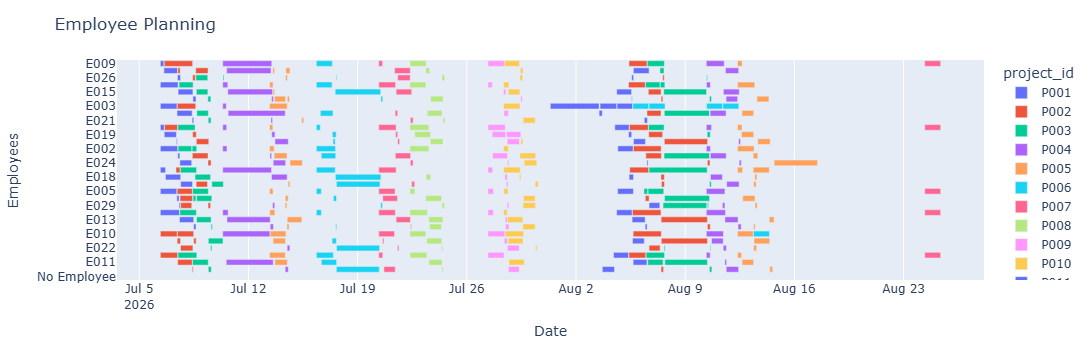

In [46]:
import plotly.express as px

planning_df["Start"] = pd.to_datetime(planning_df["start"])
planning_df["Finish"] = pd.to_datetime(planning_df["end"])

fig = px.timeline(

    planning_df,

    x_start="Start",
    x_end="Finish",

    y="employee_id",

    color="project_id",

    hover_data=[
        "feature",
        "department",
        "team",
        "worked_hours"
    ]

)

fig.update_yaxes(autorange="reversed")

fig.update_layout(

    title="Employee Planning",

    xaxis_title="Date",

    yaxis_title="Employees"

)

fig.show()

In [47]:
workload = planning_df.groupby(

    "employee_id"

)["worked_hours"].sum().reset_index()

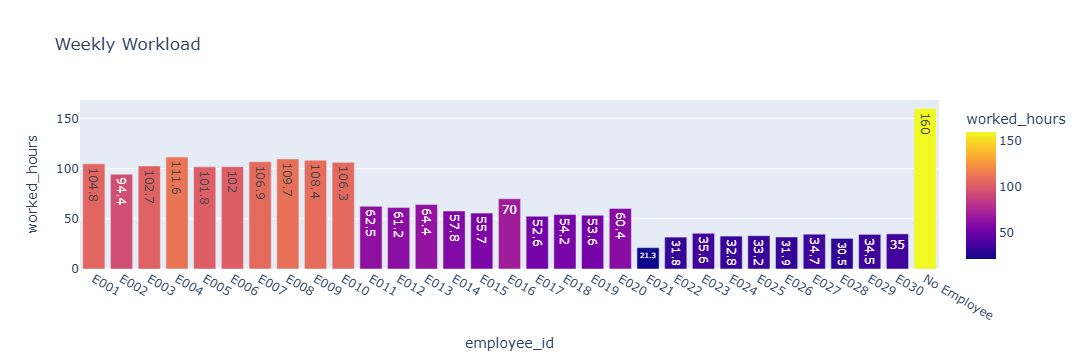

In [48]:
fig = px.bar(

    workload,

    x="employee_id",

    y="worked_hours",

    color="worked_hours",

    text="worked_hours",

    title="Weekly Workload"

)

fig.show()

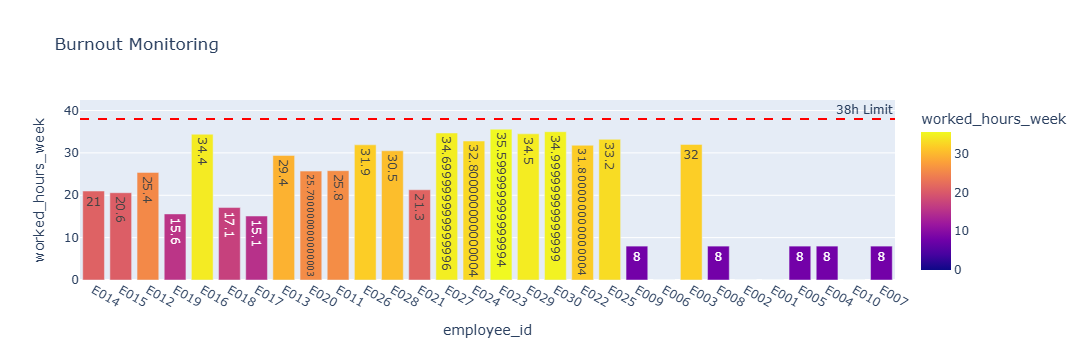

In [49]:
fig = px.bar(

    employee_score,

    x="employee_id",

    y="worked_hours_week",

    color="worked_hours_week",

    text="worked_hours_week",

    title="Burnout Monitoring"

)

fig.add_hline(

    y=38,

    line_dash="dash",

    line_color="red",

    annotation_text="38h Limit"

)

fig.show()

In [50]:
breaks = planning_df.groupby(

    "employee_id"

)["break_minutes"].sum().reset_index()

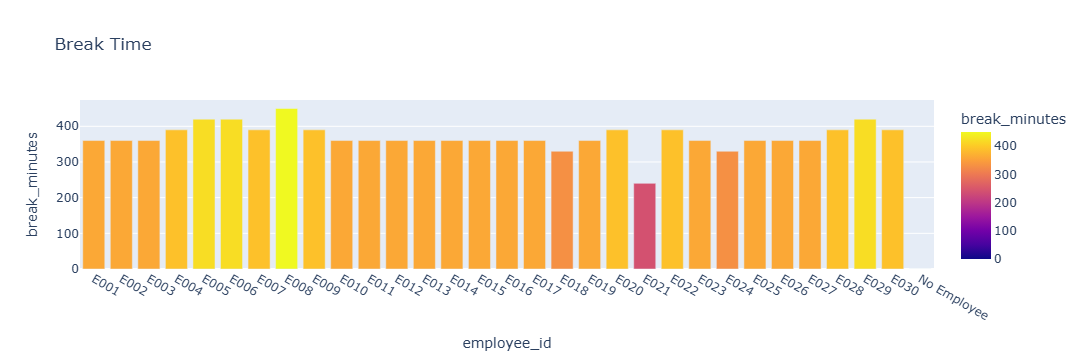

In [51]:
fig = px.bar(

    breaks,

    x="employee_id",

    y="break_minutes",

    color="break_minutes",

    title="Break Time"

)

fig.show()

In [52]:
dept = planning_df.groupby(

    "department"

).size().reset_index(name="tasks")

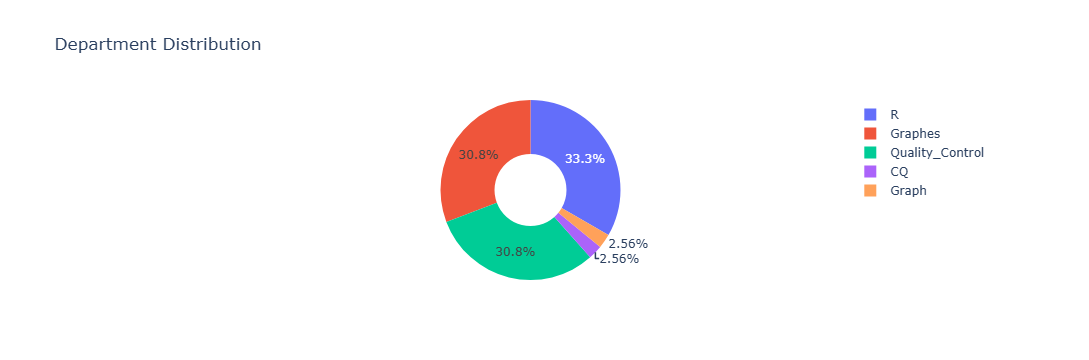

In [53]:
fig = px.pie(

    dept,

    names="department",

    values="tasks",

    hole=.4,

    title="Department Distribution"

)

fig.show()

In [54]:
progress = planning_df.groupby(

    "project_id"

).size().reset_index(name="tasks")

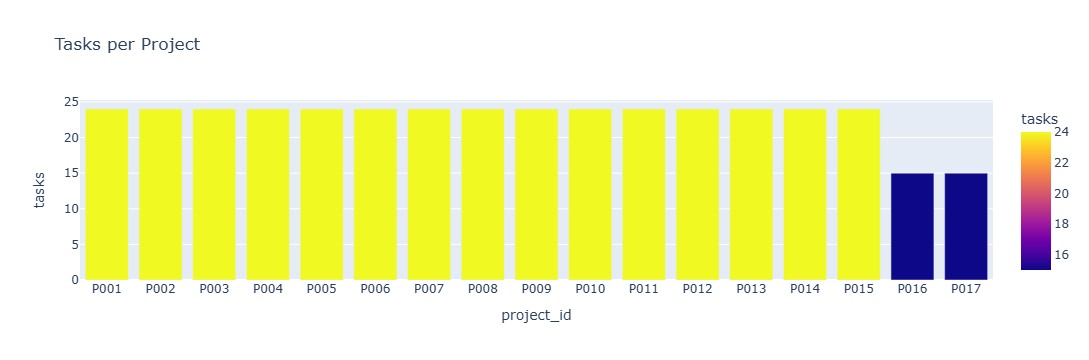

In [55]:
fig = px.bar(

    progress,

    x="project_id",

    y="tasks",

    color="tasks",

    title="Tasks per Project"

)

fig.show()

In [56]:
timeline = planning_df.copy()

timeline["date"] = timeline["Start"].dt.date

occupation = timeline.groupby(

    ["date","employee_id"]

).size().reset_index(name="tasks")

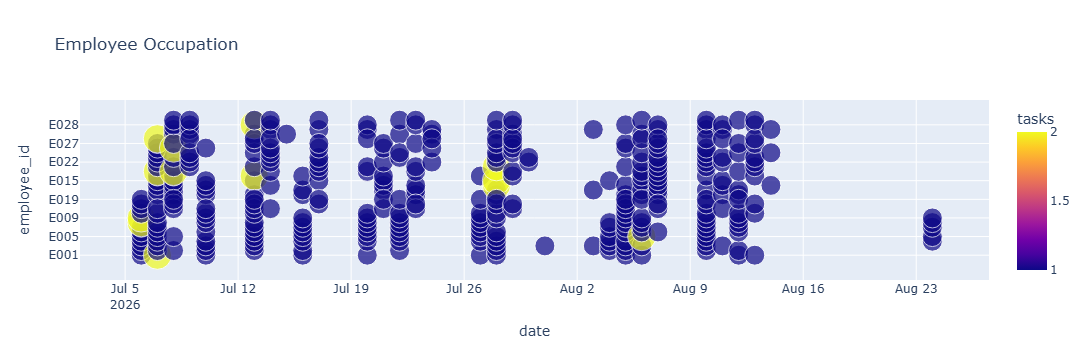

In [57]:
fig = px.scatter(

    occupation,

    x="date",

    y="employee_id",

    size="tasks",

    color="tasks",

    title="Employee Occupation"

)

fig.show()

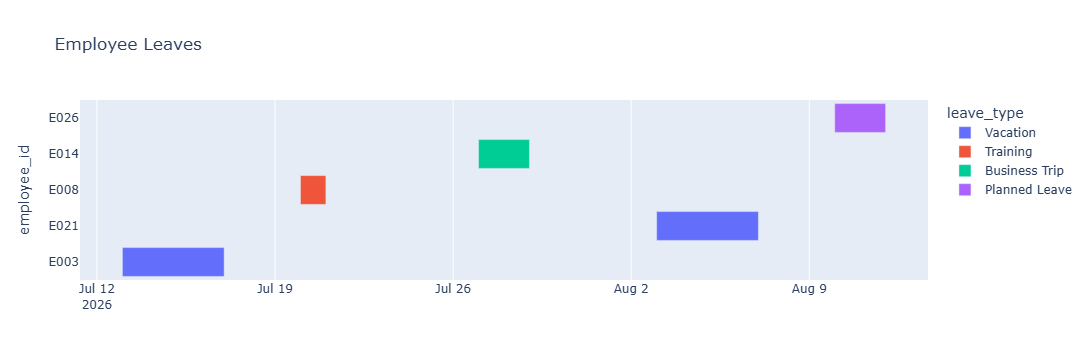

In [58]:
fig = px.timeline(

    employee_leaves,

    x_start="start_date",

    x_end="end_date",

    y="employee_id",

    color="leave_type",

    title="Employee Leaves"

)

fig.show()

In [59]:
leave_stats = employee_leaves.groupby(

    "leave_type"

).size().reset_index(name="count")

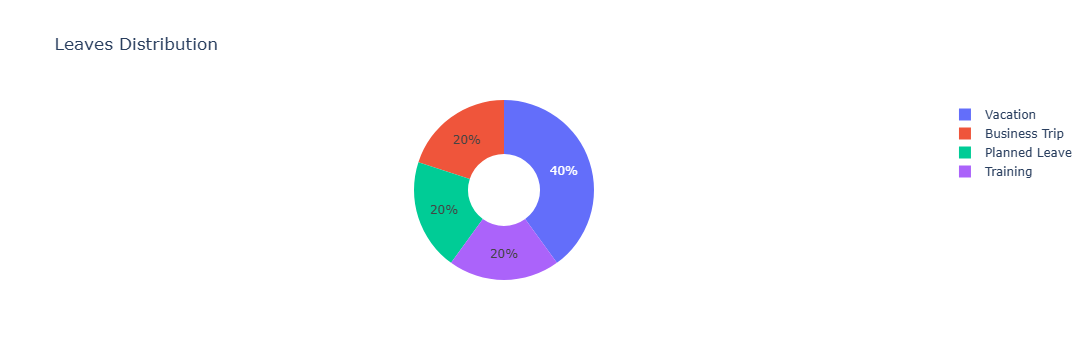

In [60]:
fig = px.pie(

    leave_stats,

    names="leave_type",

    values="count",

    hole=.4,

    title="Leaves Distribution"

)

fig.show()

In [61]:
backup_rate = (
    planning_df["backup_employee"] != "No Backup"
).mean() * 100

print(f"Backup Coverage: {backup_rate:.1f}%")

Backup Coverage: 78.5%


In [62]:
backup_stats = (
    planning_df["backup_employee"]
    .eq("No Backup")
    .map({True: "No Backup", False: "Has Backup"})
    .value_counts()
    .reset_index()
)

backup_stats.columns = ["Status", "Tasks"]

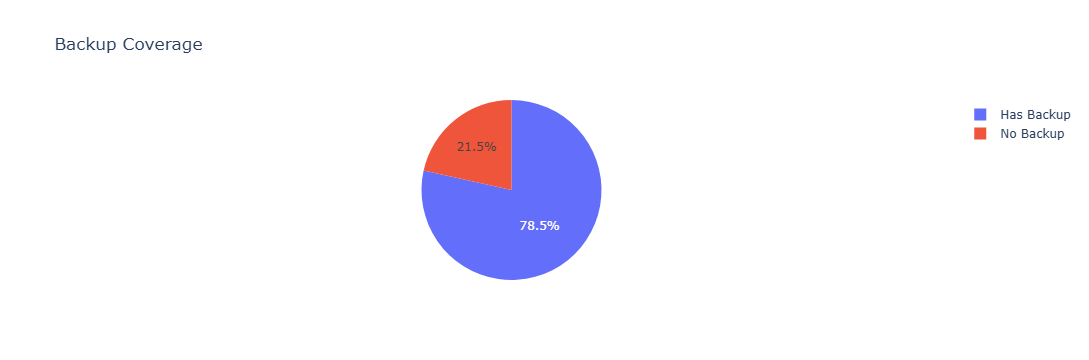

In [63]:
import plotly.express as px

fig = px.pie(
    backup_stats,
    names="Status",
    values="Tasks",
    title="Backup Coverage"
)

fig.show()

In [27]:
import pandas as pd
import uuid

def add_new_project(
    project_name,
    client,
    features,
    start_date,
    deadline
):

    global projects
    global project_tasks

    # -----------------------------
    # New Project ID
    # -----------------------------

    project_id = "P" + str(len(projects)+1).zfill(3)

    # -----------------------------
    # Add project
    # -----------------------------

    new_project = pd.DataFrame([{

        "project_id": project_id,

        "project_name": project_name,

        "client": client,

        "start_date": start_date,

        "deadline": deadline,

        "status": "Pending"

    }])

    projects = pd.concat(

        [projects,new_project],

        ignore_index=True

    )

    # -----------------------------
    # Create Tasks
    # -----------------------------

    workflow = [

        ("R",1),

        ("Graph",2),

        ("CQ",3)

    ]

    new_tasks = []

    for feature in features:

        for department,order in workflow:

            task_id = "T" + uuid.uuid4().hex[:6].upper()

            new_tasks.append({

                "task_id":task_id,

                "project_id":project_id,

                "feature":feature,

                "department":department,

                "workflow_order":order,

                "estimated_hours":8,

                "status":"Pending"

            })

    project_tasks = pd.concat(

        [

            project_tasks,

            pd.DataFrame(new_tasks)

        ],

        ignore_index=True

    )

    # -----------------------------
    # Save CSV
    # -----------------------------

    projects.to_csv(

        "projects.csv",

        index=False

    )

    project_tasks.to_csv(

        "project_tasks.csv",

        index=False

    )

    print("Project added successfully.")

    print("Running scheduler...")

In [32]:
add_new_project(

    project_name="Hospital Management System",

    client="Ministry of Health",

    features=[

        "Login",

        "Dashboard",

        "Patients",

        "Appointments",

        "Reports"

    ],

    start_date="2026-08-24",

    deadline="2026-10-01"

)

Project added successfully.
Running scheduler...
